In [3]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
    --------------------------------------- 2.4/101.7 MB 21.7 MB/s eta 0:00:05
   ---- ----------------------------------- 10.7/101.7 MB 34.3 MB/s eta 0:00:03
   ------- -------------------------------- 19.1/101.7 MB 36.0 MB/s eta 0:00:03
   ----------- ---------------------------- 28.3/101.7 MB 38.2 MB/s eta 0:00:02
   -------------- ------------------------- 37.7/101.7 MB 39.3 MB/s eta 0:00:02
   ------------------ --------------------- 45.9/101.7 MB 39.4 MB/s eta 0:00:02
   --------------------- ------------------ 55.1/101.7 MB 40.7 MB/s eta 0:00:02
   ------------------------- -------------- 64.7/101.7 MB 41.0 MB/s eta 0:00:01
   ----------------------------- ---------- 74.7/101.7 MB 41.6 MB/s eta 0:00:01
   --------------------------------- ------ 84.1/101.7 MB 41.9 MB/s eta 0:00:01
   ------------------------------------ --- 93.8/101.7 MB 42.3 MB/s eta 0:00:01
   --------------------------------------  101.4/1

In [51]:
# 03_model.ipynb

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from xgboost import XGBRegressor
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [52]:
import joblib

model_df = pd.read_parquet("../data/processed/model_df.parquet")
le_state = joblib.load("../models/le_state.pkl")
le_premise_type = joblib.load("../models/le_premise_type.pkl")

print(model_df.shape)
print(model_df.columns.tolist())

(478, 18)
['month', 'year', 'month_num', 'state', 'premise_type', 'basket_price', 'median_basket_price', 'price_std', 'num_records', 'num_items', 'num_premises', 'avg_item_volatility', 'avg_premise_index', 'avg_prev_month_price', 'month_sin', 'month_cos', 'state_encoded', 'premise_type_encoded']


In [57]:
# ── 1b. One-hot encode state and premise_type ─────────────────────────────────
model_df = pd.get_dummies(
    model_df,
    columns=["state", "premise_type"],
    drop_first=True
)

dummy_cols = [c for c in model_df.columns
              if c.startswith("state_")
              or c.startswith("premise_type_")]
print(f"Dummy columns added: {len(dummy_cols)}")
print(dummy_cols)


Dummy columns added: 22
['state_encoded', 'premise_type_encoded', 'state_Kedah', 'state_Kelantan', 'state_Melaka', 'state_Negeri Sembilan', 'state_Pahang', 'state_Perak', 'state_Perlis', 'state_Pulau Pinang', 'state_Sabah', 'state_Sarawak', 'state_Selangor', 'state_Terengganu', 'state_W.P. Kuala Lumpur', 'state_W.P. Labuan', 'state_W.P. Putrajaya', 'premise_type_Hypermarket', 'premise_type_Kedai Runcit', 'premise_type_Pasar Basah', 'premise_type_Pasar Mini', 'premise_type_Pasar Raya / Supermarket']


In [58]:
# ── 2. Prepare features ───────────────────────────────────────────────────────
FEATURES = [
    "month_sin", "month_cos",
    "year",
    "avg_item_volatility",
    "avg_premise_index",
    "avg_prev_month_price",
    "num_items",
    "num_premises",
] + dummy_cols

TARGET = "basket_price"

# Sort by time — critical for TimeSeriesSplit
model_df = model_df.sort_values("month").reset_index(drop=True)

# Drop rows where lag feature is null (first month, Nov 2025)
model_df_clean = model_df.dropna(subset=["avg_prev_month_price"]).copy()

print(f"Full model_df:    {model_df.shape[0]} rows")
print(f"After lag dropna: {model_df_clean.shape[0]} rows")
print(f"Months in model:  {sorted(model_df_clean['month'].unique())}")

X = model_df_clean[FEATURES]
y = model_df_clean[TARGET]

print([f for f in FEATURES if f.startswith("item_category_")])
print(f"Total features: {len(FEATURES)}")

Full model_df:    478 rows
After lag dropna: 398 rows
Months in model:  ['2025-12', '2026-01', '2026-02', '2026-03', '2026-04']
[]
Total features: 30


In [59]:
# ── 3. Baseline: predict last month's price ───────────────────────────────────
# This is the dumbest possible model — if we can't beat this, something is wrong

baseline_preds = model_df_clean["avg_prev_month_price"]
baseline_mae   = mean_absolute_error(y, baseline_preds)
baseline_mape  = mean_absolute_percentage_error(y, baseline_preds) * 100

print("── Naive Baseline (predict = last month's price) ──")
print(f"  MAE:  RM {baseline_mae:.4f}")
print(f"  MAPE: {baseline_mape:.2f}%")

── Naive Baseline (predict = last month's price) ──
  MAE:  RM 0.8064
  MAPE: 6.55%


In [60]:
# ── 4. Time-series cross validation ──────────────────────────────────────────
# IMPORTANT: never use random split for time series data
# TimeSeriesSplit respects temporal order — train on past, test on future

tscv = TimeSeriesSplit(n_splits=4)  # 5 months after dropping Nov, so 4 splits

def evaluate_model(model, X, y, cv, name):
    maes, mapes, r2s = [], [], []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
        
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        
        maes.append(mean_absolute_error(y_test, preds))
        mapes.append(mean_absolute_percentage_error(y_test, preds) * 100)
        r2s.append(r2_score(y_test, preds))
    
    print(f"\n── {name} ──")
    print(f"  MAE:  RM {np.mean(maes):.4f}  (±{np.std(maes):.4f})")
    print(f"  MAPE: {np.mean(mapes):.2f}%  (±{np.std(mapes):.2f}%)")
    print(f"  R²:   {np.mean(r2s):.4f}  (±{np.std(r2s):.4f})")
    return {"name": name, "mae": np.mean(maes), "mape": np.mean(mapes), "r2": np.mean(r2s)}

In [61]:
# ── 5. Train and compare models ───────────────────────────────────────────────

models = {
    "Ridge Regression":    Ridge(alpha=1.0),
    "Random Forest":       RandomForestRegressor(n_estimators=200, max_depth=6, random_state=42),
    "XGBoost":             XGBRegressor(n_estimators=300, learning_rate=0.05, 
                                        max_depth=4, random_state=42, verbosity=0),
}

results = []
for name, model in models.items():
    result = evaluate_model(model, X, y, tscv, name)
    results.append(result)

results_df = pd.DataFrame(results).sort_values("mape")
print("\n── Summary ──")
print(results_df.to_string(index=False))


── Ridge Regression ──
  MAE:  RM 0.3821  (±0.0845)
  MAPE: 3.15%  (±0.78%)
  R²:   0.8047  (±0.0847)

── Random Forest ──
  MAE:  RM 0.4502  (±0.1265)
  MAPE: 3.75%  (±1.23%)
  R²:   0.7497  (±0.0816)

── XGBoost ──
  MAE:  RM 0.3886  (±0.0949)
  MAPE: 3.25%  (±1.01%)
  R²:   0.7952  (±0.1004)

── Summary ──
            name      mae     mape       r2
Ridge Regression 0.382084 3.148955 0.804701
         XGBoost 0.388589 3.246945 0.795168
   Random Forest 0.450217 3.748672 0.749660


In [62]:
# ── 6. Train final model on all data ─────────────────────────────────────────
from sklearn.linear_model import Ridge

final_model = Ridge(alpha=1.0)
final_model.fit(X, y)

train_preds = final_model.predict(X)
print(f"Final model in-sample MAE:  RM {mean_absolute_error(y, train_preds):.4f}")
print(f"Final model in-sample MAPE: {mean_absolute_percentage_error(y, train_preds)*100:.2f}%")
joblib.dump(final_model, "../models/ridge_basket_price.pkl")

Final model in-sample MAE:  RM 0.2496
Final model in-sample MAPE: 2.03%


['../models/ridge_basket_price.pkl']

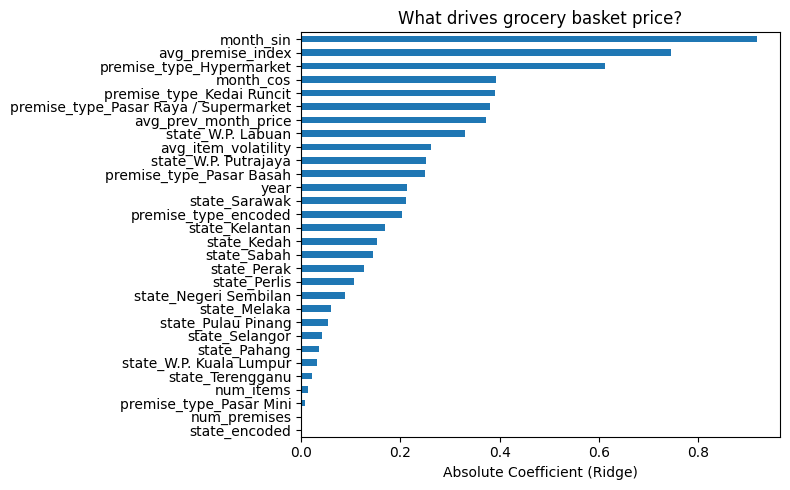

month_sin                                0.918284
avg_premise_index                        0.744019
premise_type_Hypermarket                 0.612532
month_cos                                0.393125
premise_type_Kedai Runcit                0.390078
premise_type_Pasar Raya / Supermarket    0.381028
avg_prev_month_price                     0.371622
state_W.P. Labuan                        0.330201
avg_item_volatility                      0.262210
state_W.P. Putrajaya                     0.251203
premise_type_Pasar Basah                 0.249171
year                                     0.213023
state_Sarawak                            0.211106
premise_type_encoded                     0.202224
state_Kelantan                           0.169695
state_Kedah                              0.153747
state_Sabah                              0.144297
state_Perak                              0.126207
state_Perlis                             0.106490
state_Negeri Sembilan                    0.089027


In [64]:
# ── 7. Feature importance (Ridge coefficients) ────────────────────────────────

importances = pd.Series(
    np.abs(final_model.coef_), index=FEATURES
).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh")
plt.xlabel("Absolute Coefficient (Ridge)")
plt.title("What drives grocery basket price?")
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False))

In [65]:
joblib.dump(final_model, "../models/ridge_basket_price.pkl")
model_df_clean.to_parquet("../data/processed/model_predictions.parquet", index=False)